<a href="https://colab.research.google.com/github/sanjaysaravanan8887/Rainwater-Quality-Classification-System-With-Adaptive-First-Flush/blob/main/RainWater_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [4]:
df= pd.read_csv("/content/rainwater_classification_dataset_v2_balanced.csv")

In [5]:
df.shape

(40000, 8)

In [6]:
df.head()

,ph,tds_ppm,turbidity_ntu,temperature_c,dry_days_before_rain,rainwater_quality_score,water_class,recommended_action
0,6.25,360.3,61.33,30.3,33,32.5,Poor_Needs_Treatment,Do not store directly; send to treatment/filter
1,6.42,99.8,3.20,24.8,0,83.2,Excellent_Store,Best for storage; disinfect before drinking use
2,6.19,174.5,2.56,29.0,1,75.1,Good_Store_After_Filter,Store after filtration; disinfect if used for ...
3,6.38,69.7,12.10,29.7,5,65.7,Good_Store_After_Filter,Store after filtration; disinfect if used for ...
4,5.80,391.4,54.74,25.0,26,25.6,Poor_Needs_Treatment,Do not store directly; send to treatment/filter


In [7]:
df.tail()

,ph,tds_ppm,turbidity_ntu,temperature_c,dry_days_before_rain,rainwater_quality_score,water_class,recommended_action
39995,6.07,63.5,8.80,26.6,7,66.8,Good_Store_After_Filter,Store after filtration; disinfect if used for ...
39996,5.83,382.3,93.12,27.1,17,27.5,Poor_Needs_Treatment,Do not store directly; send to treatment/filter
39997,5.87,439.8,86.05,19.6,30,22.0,Reject_First_Flush,Continue diverting to first-flush waste outlet
39998,6.06,108.5,6.69,25.6,2,67.4,Good_Store_After_Filter,Store after filtration; disinfect if used for ...
39999,6.15,110.1,0.03,31.6,0,84.3,Excellent_Store,Best for storage; disinfect before drinking use


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ph                       40000 non-null  float64
 1   tds_ppm                  40000 non-null  float64
 2   turbidity_ntu            40000 non-null  float64
 3   temperature_c            40000 non-null  float64
 4   dry_days_before_rain     40000 non-null  int64  
 5   rainwater_quality_score  40000 non-null  float64
 6   water_class              40000 non-null  object 
 7   recommended_action       40000 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 2.4+ MB


In [9]:
df.columns

Index(['ph', 'tds_ppm', 'turbidity_ntu', 'temperature_c',
       'dry_days_before_rain', 'rainwater_quality_score', 'water_class',
       'recommended_action'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
ph,0
tds_ppm,0
turbidity_ntu,0
temperature_c,0
dry_days_before_rain,0
rainwater_quality_score,0
water_class,0
recommended_action,0


In [11]:
df = df.drop(columns=["recommended_action"])
df = df.drop(columns=["rainwater_quality_score"])


In [12]:
df.head()

,ph,tds_ppm,turbidity_ntu,temperature_c,dry_days_before_rain,water_class
0,6.25,360.3,61.33,30.3,33,Poor_Needs_Treatment
1,6.42,99.8,3.20,24.8,0,Excellent_Store
2,6.19,174.5,2.56,29.0,1,Good_Store_After_Filter
3,6.38,69.7,12.10,29.7,5,Good_Store_After_Filter
4,5.80,391.4,54.74,25.0,26,Poor_Needs_Treatment


In [13]:
df["water_class"].unique()

array(['Poor_Needs_Treatment', 'Excellent_Store',
       'Good_Store_After_Filter', 'Reject_First_Flush',
       'Fair_Non_Potable_Use'], dtype=object)

In [14]:
df["water_class"] = df["water_class"].map({"Reject_First_Flush": 0,"Poor_Needs_Treatment": 1,"Fair_Non_Potable_Use": 2,"Good_Store_After_Filter": 3,"Excellent_Store": 4})
sns.set(style="whitegrid")

In [15]:
df.describe()

,ph,tds_ppm,turbidity_ntu,temperature_c,dry_days_before_rain,water_class
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,6.044725,215.920505,35.323635,27.510500,14.556075,2.000000
std,0.284569,159.484783,34.286687,2.985184,12.232287,1.414231
min,4.710000,5.000000,0.030000,18.000000,0.000000,0.000000
25%,5.850000,81.600000,3.860000,25.500000,5.000000,1.000000
50%,6.070000,171.100000,21.740000,27.500000,11.000000,2.000000
75%,6.240000,348.100000,67.172500,29.500000,23.000000,3.000000
max,7.160000,802.200000,95.000000,38.000000,45.000000,4.000000


In [16]:
print(df["water_class"].value_counts())

water_class
1    8000
4    8000
3    8000
0    8000
2    8000
Name: count, dtype: int64


In [17]:
df.columns

Index(['ph', 'tds_ppm', 'turbidity_ntu', 'temperature_c',
       'dry_days_before_rain', 'water_class'],
      dtype='object')

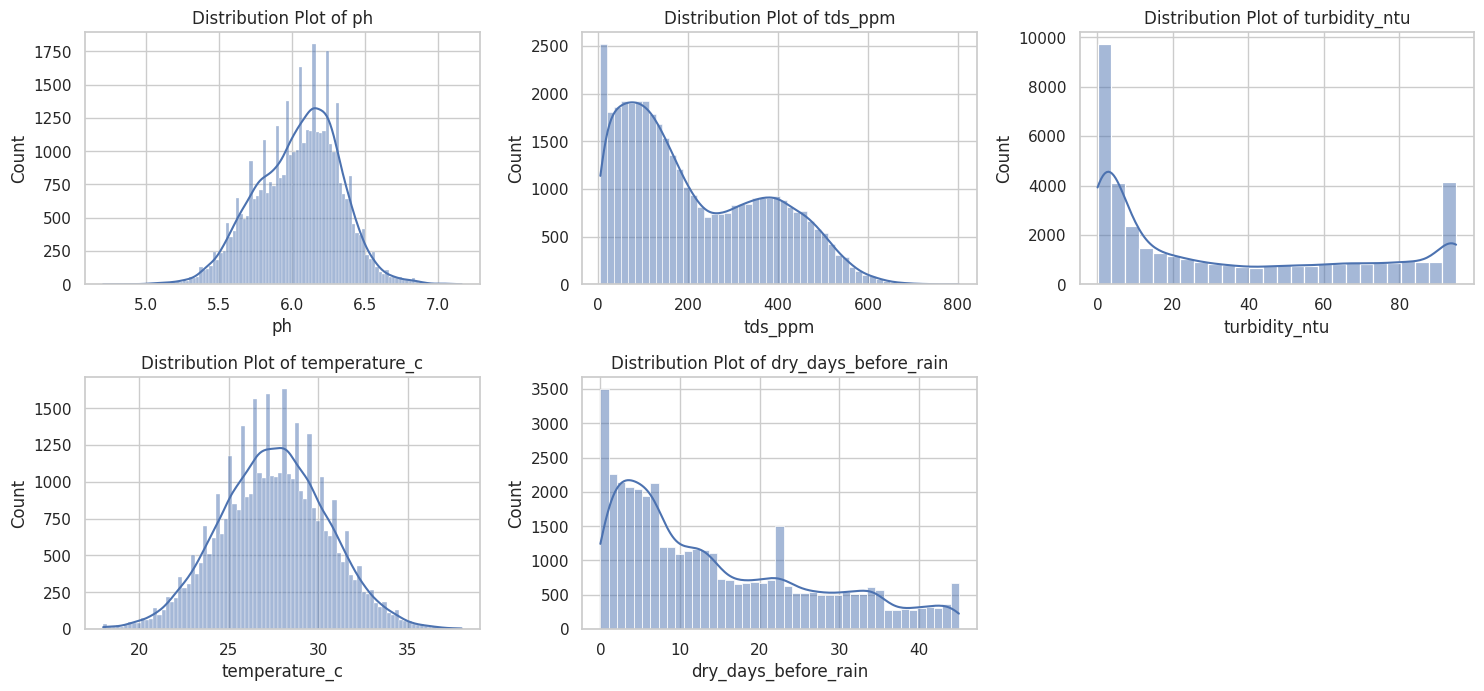

In [18]:
plt.figure(figsize=(15,10))

for i, col in enumerate(['ph', 'tds_ppm', 'turbidity_ntu', 'temperature_c',
       'dry_days_before_rain'], 1):
  plt.subplot(3,3,i)
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution Plot of {col}")

plt.tight_layout()
plt.show()

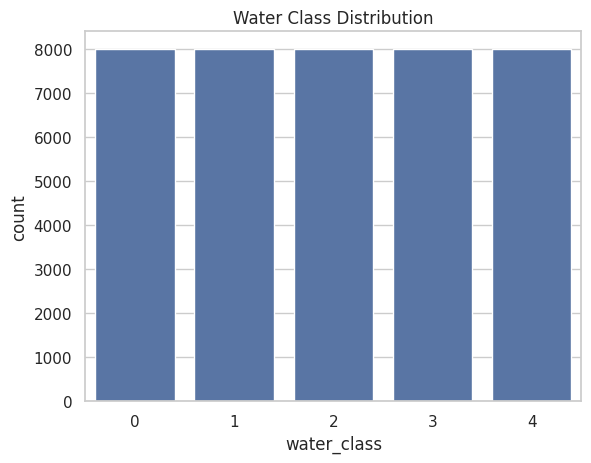

In [19]:
sns.countplot(data=df, x="water_class")
plt.title("Water Class Distribution")
plt.show()

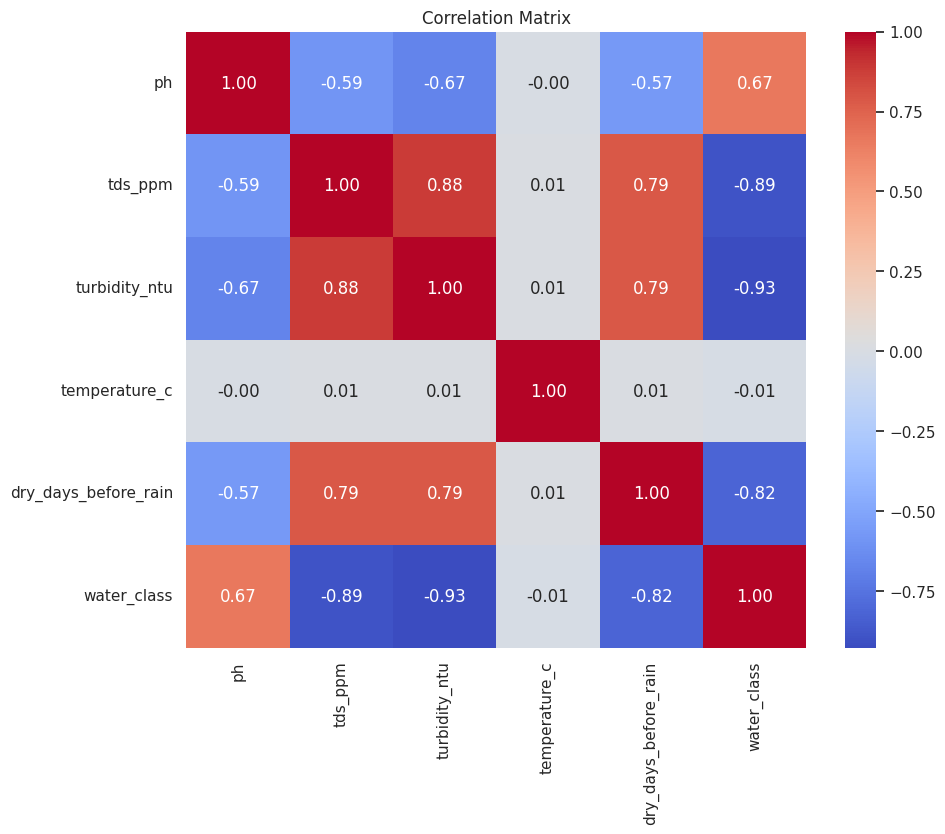

In [20]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

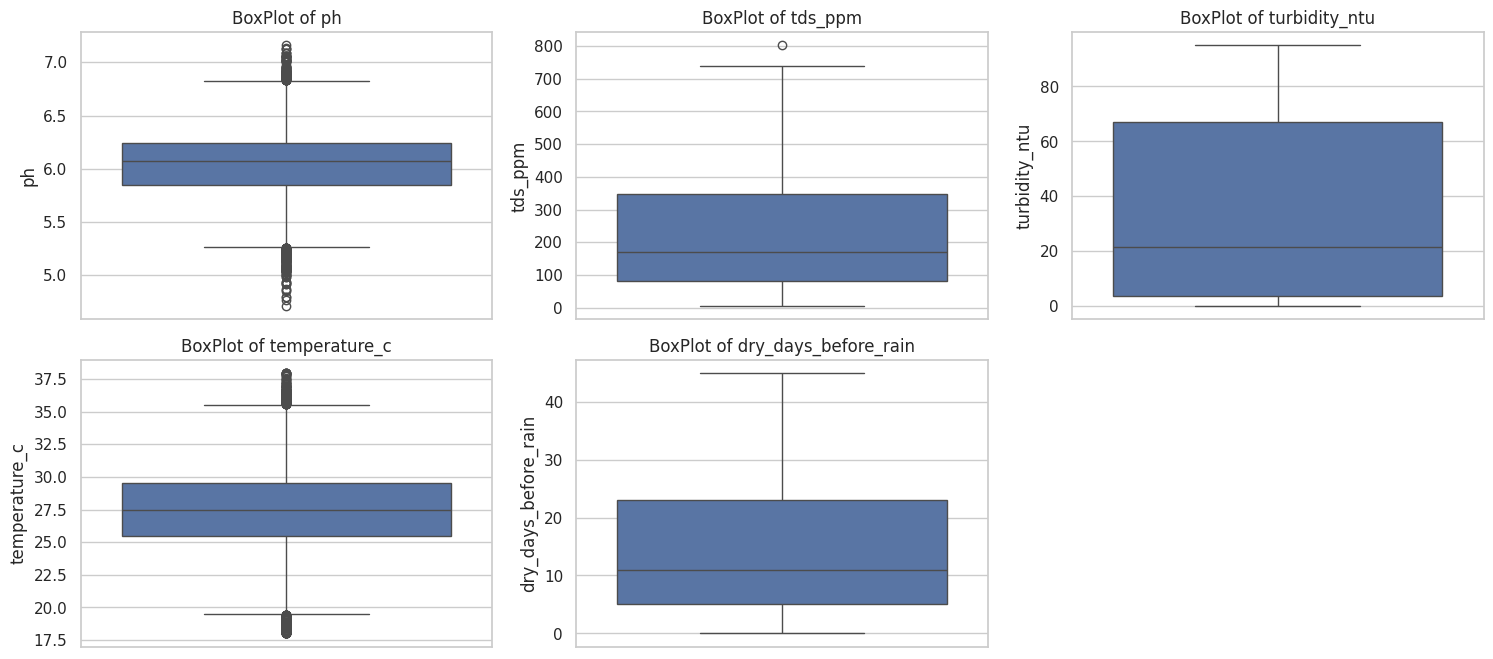

In [21]:
plt.figure(figsize=(15,10))

for i, col in enumerate(['ph', 'tds_ppm', 'turbidity_ntu', 'temperature_c',
       'dry_days_before_rain'], 1):
  plt.subplot(3,3,i)
  sns.boxplot(df[col])
  plt.title(f"BoxPlot of {col}")

plt.tight_layout()
plt.show()

In [22]:
X = df.drop(columns=["water_class"])
Y = df["water_class"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [23]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

Decision Tree
Accuracy : 0.9575

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1600
           1       0.95      0.95      0.95      1600
           2       0.97      0.97      0.97      1600
           3       0.95      0.94      0.95      1600
           4       0.96      0.96      0.96      1600

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000



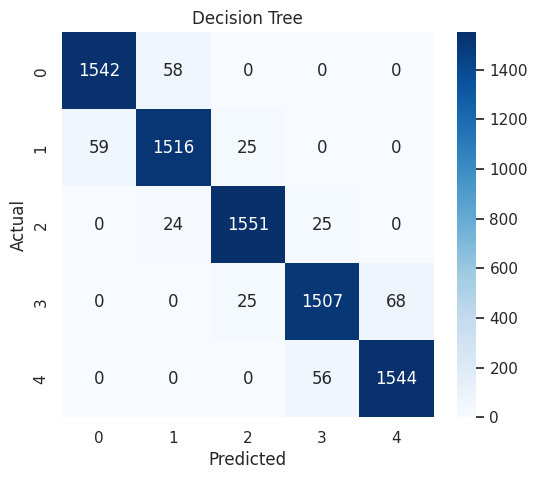

Random Forest
Accuracy : 0.9745

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1600
           1       0.98      0.96      0.97      1600
           2       0.98      0.98      0.98      1600
           3       0.97      0.96      0.97      1600
           4       0.97      0.98      0.98      1600

    accuracy                           0.97      8000
   macro avg       0.97      0.97      0.97      8000
weighted avg       0.97      0.97      0.97      8000



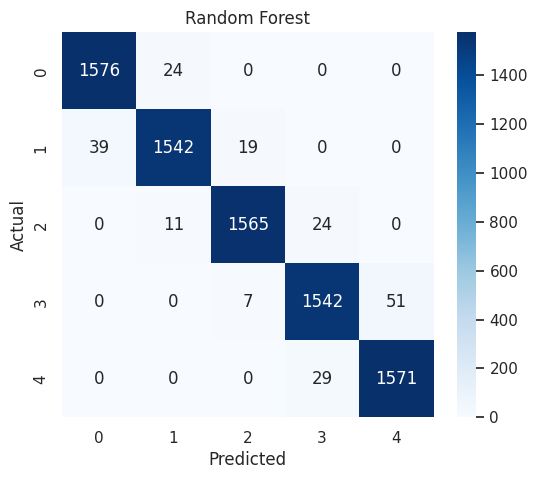

XGBoost
Accuracy : 0.9734

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1600
           1       0.98      0.96      0.97      1600
           2       0.98      0.98      0.98      1600
           3       0.97      0.96      0.96      1600
           4       0.96      0.98      0.97      1600

    accuracy                           0.97      8000
   macro avg       0.97      0.97      0.97      8000
weighted avg       0.97      0.97      0.97      8000



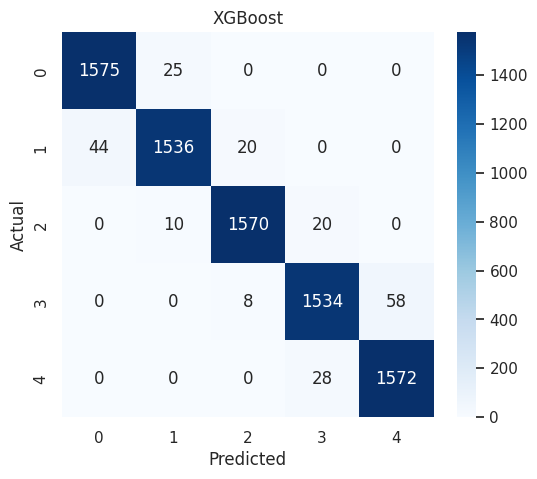

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 952
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 5
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
LightGBM
Accuracy : 0.9762

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1600
           1       0.98      0.97      0.97      1600
           2       0.99      0.98      0.98      1600
           3       0.97      0.96      0.97      1600
           4       0.97      0.98      0.97      1600

    accuracy                           0.98      8000
   macro avg

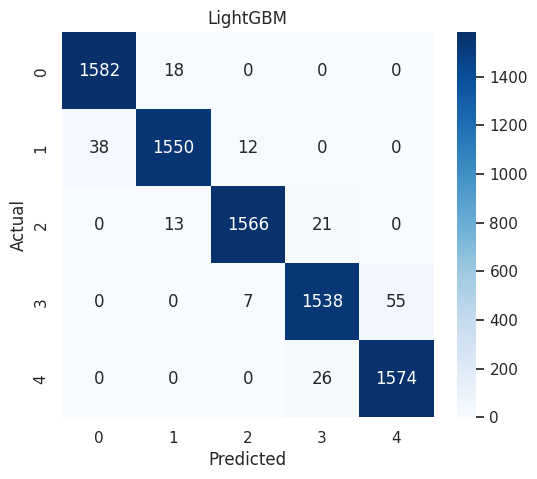

CatBoost
Accuracy : 0.9778

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1600
           1       0.98      0.97      0.98      1600
           2       0.99      0.98      0.98      1600
           3       0.97      0.96      0.97      1600
           4       0.97      0.99      0.98      1600

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



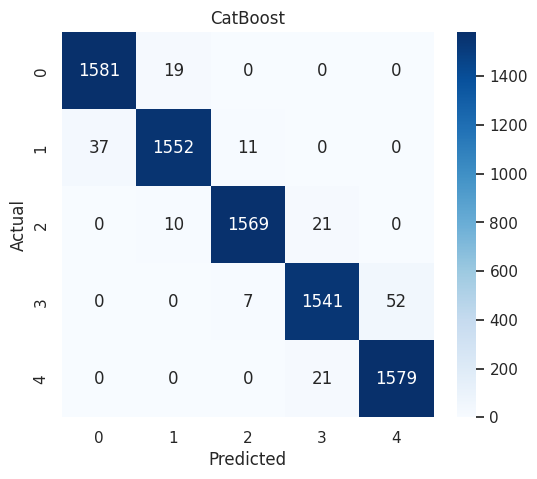

In [24]:
results = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(Y_test, pred)

    results.append([name, acc])

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {acc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(Y_test, pred))

    cm = confusion_matrix(Y_test, pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [25]:
best_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

best_model.fit(X_train, Y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [26]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Training Accuracy:", accuracy_score(Y_train, train_pred))
print("Testing Accuracy:", accuracy_score(Y_test, test_pred))

Training Accuracy: 0.9864375
Testing Accuracy: 0.97775


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    CatBoostClassifier(verbose=0, random_state=42),
    X,
    Y,
    cv=5,
    scoring="accuracy"
)

print("Accuracy of each fold:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Accuracy of each fold: [0.974625 0.975375 0.976125 0.974375 0.975125]
Mean Accuracy: 0.975125
Standard Deviation: 0.0006123724356958087


In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
2         turbidity_ntu   37.943272
1               tds_ppm   24.590118
0                    ph   16.477548
4  dry_days_before_rain   16.138510
3         temperature_c    4.850552


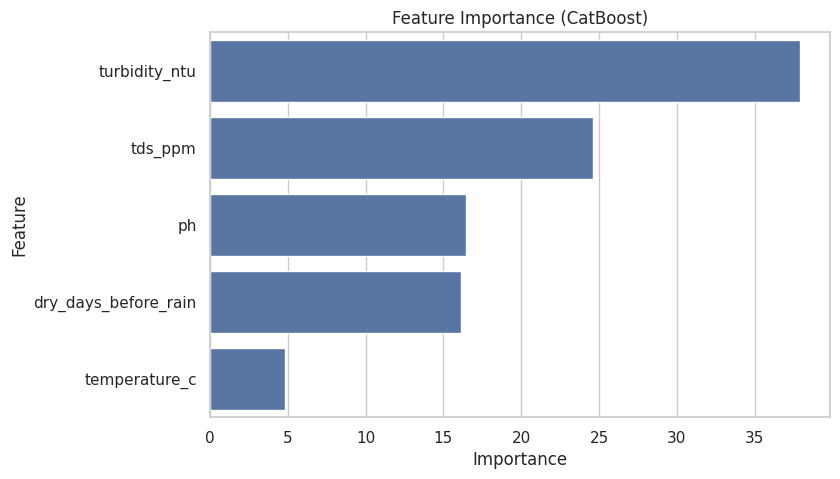

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (CatBoost)")
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

param_grid = {
    "iterations": [500],
    "depth": [6],
    "learning_rate": [0.05]
}

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'depth': 6, 'iterations': 500, 'learning_rate': 0.05}
Best CV Accuracy: 0.9747187431144698


In [31]:
best_tuned_model = grid_search.best_estimator_

tuned_pred = best_tuned_model.predict(X_test)

print("Tuned Test Accuracy:", accuracy_score(Y_test, tuned_pred))
print(classification_report(Y_test, tuned_pred))

Tuned Test Accuracy: 0.9765
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1600
           1       0.98      0.96      0.97      1600
           2       0.99      0.98      0.98      1600
           3       0.97      0.96      0.97      1600
           4       0.97      0.99      0.98      1600

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



In [34]:
sample = pd.DataFrame([{
    "ph": 6.8,
    "tds_ppm": 120,
    "turbidity_ntu": 2.5,
    "temperature_c": 27,
    "dry_days_before_rain": 4
}])

prediction = best_tuned_model.predict(sample)
pred = int(prediction[0])

water_class = {
    0: "Reject_First_Flush",
    1: "Poor_Needs_Treatment",
    2: "Fair_Non_Potable_Use",
    3: "Good_Store_After_Filter",
    4: "Excellent_Store"
}

recommendation = {
    0: "Continue diverting the water to the first flush outlet. Do not store this water.",
    1: "Water quality is poor. Do not store directly. Send it for proper treatment and filtration.",
    2: "Suitable for non-potable uses such as gardening, floor cleaning and toilet flushing after basic filtration.",
    3: "Store the water after filtration. Disinfection is recommended before drinking.",
    4: "Excellent quality rainwater. Safe for storage. Disinfection is recommended before drinking."
}

print("Predicted Class Number :", pred)
print("Water Class            :", water_class[pred])
print("Recommendation         :", recommendation[pred])

Predicted Class Number : 4
Water Class            : Excellent_Store
Recommendation         : Excellent quality rainwater. Safe for storage. Disinfection is recommended before drinking.


In [32]:
import joblib

joblib.dump(best_tuned_model, "rainwater_catboost_model.pkl")

['rainwater_catboost_model.pkl']

In [35]:
from google.colab import files
files.download("rainwater_catboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>